# PR Throughput Analysis

**Section 3 of Baseline System Productivity Report**

> A high-level proxy for engineering output volume.

## What we're measuring

1. **Raw throughput**: Total PRs merged over time (absolute volume)
2. **Throughput per contributor**: PRs merged ÷ unique contributors (normalized)
   - If raw goes up but per-capita is flat → growth is from hiring
   - If per-capita goes up → actual productivity improvement
3. **Breakdown by Area**: Using top-level Swarmia teams (Core Experience, Data, Gaming, Platform, Player, Social, Sports)

## Data caveat

Area breakdown uses Swarmia's `owner_team_names` filtered to top-level teams. This is historically accurate (team assignment at time of PR) but team names have evolved over time. We exclude AI Pilot, Productivity, Quant, and Test Team from the breakdown.

In [50]:
import snowflake.connector
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Connect using SSO (will open browser)
conn = snowflake.connector.connect(
    account='wt74883-sb_prod',
    user='jeroen.vaelen@happening.xyz',
    authenticator='externalbrowser'
)

def run_query(sql):
    """Run SQL and return pandas DataFrame"""
    cur = conn.cursor()
    cur.execute(sql)
    df = cur.fetch_pandas_all()
    df.columns = df.columns.str.lower()
    return df

print('Connected!')

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/2c8cda8f-751e-4798-8680-5761f91d4e40/saml2?SAMLRequest=lZJRb9owFIX%2FSuQ9J3FCIMECKlbEylQYK5SHvUwmdqhXx858HQL%2Fvk4AqXtopb1Fzjn%2Bju%2B5o7tTKb0jNyC0GqMowMjjKtdMqMMYPW%2FnfoY8sFQxKrXiY3TmgO4mI6ClrMi0ti%2Fqif%2BtOVjPXaSAtD%2FGqDaKaAoCiKIlB2JzspkuH0kcYEIBuLEOh64WBsKxXqytSBg2TRM0vUCbQxhjjEM8DJ2qlXxB7xDV54zKaKtzLW%2BWk3vTB4goxEmLcApHWF%2BNX4W6jOAzyv4iAvKw3a799Y%2FNFnnT2%2BvutYK65GbDzVHk%2FPnp8RIA2gQ2TbKs58P%2Bt0vKAlC6KSR95bkuq9q6OwP3FRachVIfhJvUYjZG1atgbNcrRX86Px9Os6oUq2%2BbaL9Kfi7%2F7I%2B7h7S3O%2BtHWnyXi2K3zJG3u%2FUat70uAGq%2BUG2b1h3heODj2MfDLc5IPCB4GERp7xfyZq5NoajtnLfIXY6gFLnRoAurlRSKdynjPMsZzQo%2F7UfcT9Jh5meDDPv9dBAVw4glPMFh21mMLntDuiBm8n%2FTGIXvvdcFXLlOFrO1liI%2Fe3NtSmo%2FriwKou5EML%2FopISXVMgpY4YDuOqk1M294dS6Pbem5iicXKj%2FbvrkDQ%3D%3D&RelayState=ver%3A3-hint%3A491009301606406-ETMsDgAAAZxBghGVABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEKGNh9qRG8UE%2Bm246u

 pip install snowflake-connector-python[secure-local-storage]


## 1. Data Exploration

First, let's understand what data we have.

In [66]:
# What's the date range and volume?
df_overview = run_query("""
SELECT 
  MIN(github_created_at)::DATE as earliest_pr,
  MAX(github_created_at)::DATE as latest_pr,
  COUNT(*) as total_prs,
  COUNT(CASE WHEN pr_status = 'MERGED' THEN 1 END) as merged_prs,
  COUNT(CASE WHEN pr_status = 'OPEN' THEN 1 END) as open_prs,
  COUNT(CASE WHEN pr_status = 'CLOSED' THEN 1 END) as closed_prs,
  COUNT(DISTINCT author_id) as unique_authors
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
""")

print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Date range: {df_overview['earliest_pr'].iloc[0]} to {df_overview['latest_pr'].iloc[0]}")
print(f"Total PRs: {df_overview['total_prs'].iloc[0]:,}")
print(f"  - Merged: {df_overview['merged_prs'].iloc[0]:,}")
print(f"  - Open: {df_overview['open_prs'].iloc[0]:,}")
print(f"  - Closed: {df_overview['closed_prs'].iloc[0]:,}")
print(f"Unique authors: {df_overview['unique_authors'].iloc[0]:,}")
print("=" * 50)

DATA OVERVIEW
Date range: 2019-12-19 to 2026-02-08
Total PRs: 347,437
  - Merged: 296,585
  - Open: 5,948
  - Closed: 44,904
Unique authors: 920


In [67]:
# What teams do we have?
df_teams = run_query("""
SELECT 
  f.value::string as team_name,
  COUNT(*) as pr_count
FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
LATERAL FLATTEN(input => pr.owner_team_names) f
WHERE pr.pr_status = 'MERGED'
GROUP BY 1
ORDER BY 2 DESC
""")

print(f"Total teams: {len(df_teams)}")
print(f"\nTop 20 teams by PR count:")
df_teams.head(20)

Total teams: 84

Top 20 teams by PR count:


,team_name,pr_count
0,Sports,44802
1,Player,33178
2,Data,25211
3,Platform,20552
4,Gaming,14452
5,Offer Platform,9865
6,Betting Platform,9722
7,Product Data Platform,9606
8,Player Engagement,9552
9,Productivity,8079


## 2. Org-wide Throughput (Raw)

Total merged PRs per month across the organization.

In [68]:
# Monthly merged PRs (excluding current incomplete month)
df_monthly = run_query("""
SELECT 
  DATE_TRUNC('month', github_created_at)::DATE as month,
  COUNT(*) as prs_merged,
  COUNT(DISTINCT author_id) as contributors
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND github_created_at IS NOT NULL
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)  -- exclude current month
GROUP BY 1
ORDER BY 1
""")

# Calculate per-capita and add datetime column for filtering
df_monthly['prs_per_contributor'] = (df_monthly['prs_merged'] / df_monthly['contributors']).round(1)
df_monthly['month_dt'] = pd.to_datetime(df_monthly['month'])

print(f"Data through: {df_monthly['month'].max()}")
print(f"Note: Early years (2020-2021) have sparse data - use recent averages for baseline")
df_monthly.tail(10)

Data through: 2026-01-01
Note: Early years (2020-2021) have sparse data - use recent averages for baseline


,month,prs_merged,contributors,prs_per_contributor,month_dt
51,2025-04-01,7456,406,18.4,2025-04-01
52,2025-05-01,7503,417,18.0,2025-05-01
53,2025-06-01,6571,417,15.8,2025-06-01
54,2025-07-01,8131,449,18.1,2025-07-01
55,2025-08-01,6917,447,15.5,2025-08-01
56,2025-09-01,8102,494,16.4,2025-09-01
57,2025-10-01,9222,528,17.5,2025-10-01
58,2025-11-01,8392,528,15.9,2025-11-01
59,2025-12-01,7593,523,14.5,2025-12-01
60,2026-01-01,8197,553,14.8,2026-01-01


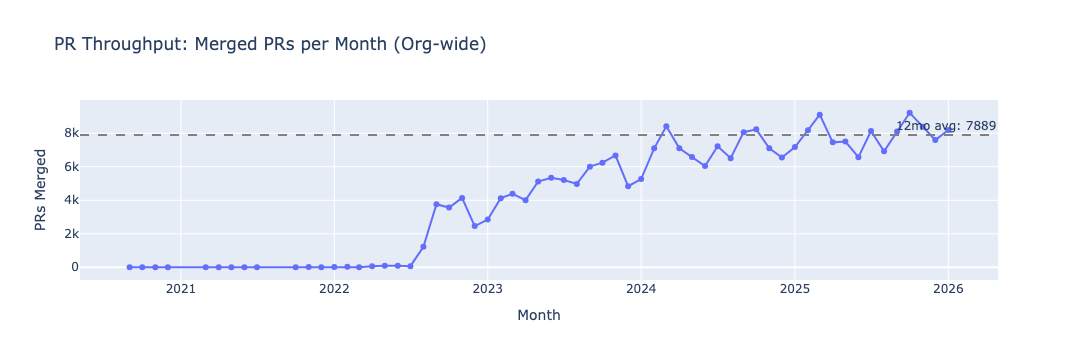


Baseline (last 12 months): 7889 PRs merged per month


In [69]:
# Visualize raw throughput
fig = px.line(df_monthly, x='month', y='prs_merged',
              title='PR Throughput: Merged PRs per Month (Org-wide)',
              markers=True)
fig.update_layout(yaxis_title='PRs Merged', xaxis_title='Month')

# Add 12-month average line (more meaningful than all-time given sparse early data)
recent_12mo = df_monthly[df_monthly['month_dt'] >= df_monthly['month_dt'].max() - pd.DateOffset(months=12)]
avg_prs_12mo = recent_12mo['prs_merged'].mean()
fig.add_hline(y=avg_prs_12mo, line_dash="dash", line_color="gray", 
              annotation_text=f"12mo avg: {avg_prs_12mo:.0f}")

fig.show()

print(f"\nBaseline (last 12 months): {avg_prs_12mo:.0f} PRs merged per month")

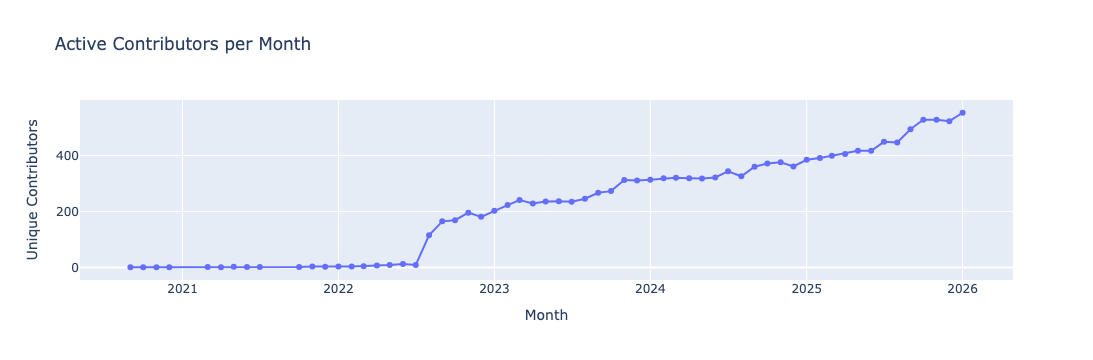

In [70]:
# Visualize contributors over time
fig = px.line(df_monthly, x='month', y='contributors',
              title='Active Contributors per Month',
              markers=True)
fig.update_layout(yaxis_title='Unique Contributors', xaxis_title='Month')
fig.show()

## 3. Throughput per Contributor (Normalized)

This tells us if productivity per person is improving, or if throughput growth is just from hiring.

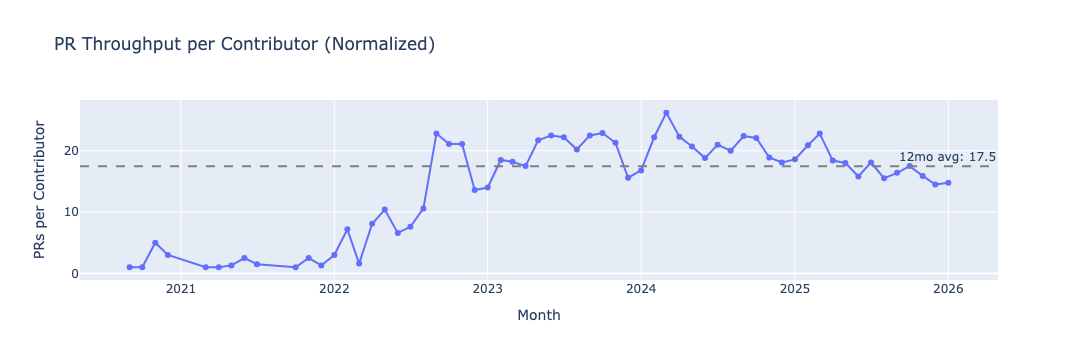


Baseline (last 12 months): 17.5 PRs per contributor per month


In [71]:
# Visualize per-capita throughput
fig = px.line(df_monthly, x='month', y='prs_per_contributor',
              title='PR Throughput per Contributor (Normalized)',
              markers=True)
fig.update_layout(yaxis_title='PRs per Contributor', xaxis_title='Month')

# Add 12-month average line
recent_12mo = df_monthly[df_monthly['month_dt'] >= df_monthly['month_dt'].max() - pd.DateOffset(months=12)]
avg_per_capita_12mo = recent_12mo['prs_per_contributor'].mean()
fig.add_hline(y=avg_per_capita_12mo, line_dash="dash", line_color="gray",
              annotation_text=f"12mo avg: {avg_per_capita_12mo:.1f}")

fig.show()

print(f"\nBaseline (last 12 months): {avg_per_capita_12mo:.1f} PRs per contributor per month")

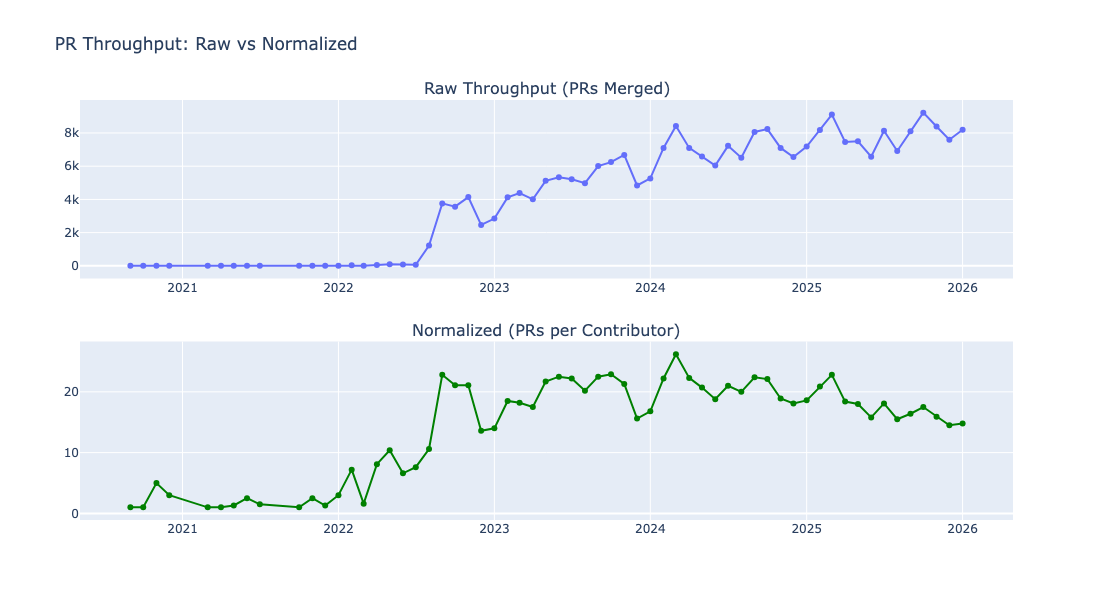

In [72]:
# Combined view: Raw vs Normalized
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=('Raw Throughput (PRs Merged)', 'Normalized (PRs per Contributor)'),
                    vertical_spacing=0.15)

fig.add_trace(
    go.Scatter(x=df_monthly['month'], y=df_monthly['prs_merged'], 
               mode='lines+markers', name='PRs Merged'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df_monthly['month'], y=df_monthly['prs_per_contributor'], 
               mode='lines+markers', name='PRs per Contributor', line=dict(color='green')),
    row=2, col=1
)

fig.update_layout(height=600, title_text='PR Throughput: Raw vs Normalized', showlegend=False)
fig.show()

# Export manually: fig.write_image('pr-throughput-raw-vs-normalized.png')

In [73]:
# Calculate YoY growth
df_monthly['year'] = df_monthly['month_dt'].dt.year
df_monthly['month_num'] = df_monthly['month_dt'].dt.month

# Compare same months YoY
df_yoy = df_monthly.pivot(index='month_num', columns='year', values='prs_merged')
print("PRs Merged by Month and Year:")
df_yoy

PRs Merged by Month and Year:


year,2020,2021,2022,2023,2024,2025,2026
month_num,,,,,,,
1,NaN,NaN,12.0,2845.0,5265.0,7178.0,8197.0
2,NaN,NaN,29.0,4123.0,7097.0,8183.0,NaN
3,NaN,2.0,8.0,4387.0,8416.0,9110.0,NaN
4,NaN,1.0,57.0,4006.0,7101.0,7456.0,NaN
5,NaN,4.0,94.0,5117.0,6585.0,7503.0,NaN
6,NaN,5.0,86.0,5336.0,6040.0,6571.0,NaN
7,NaN,3.0,68.0,5209.0,7226.0,8131.0,NaN
8,NaN,NaN,1221.0,4977.0,6511.0,6917.0,NaN
9,1.0,NaN,3761.0,6005.0,8063.0,8102.0,NaN


## 4. Breakdown by Area

Filtered to top-level Swarmia teams (excluding AI Pilot, Productivity, Quant, Test Team).

**Caveat**: Uses Swarmia's `owner_team_names` which reflects the team that owned the PR at the time. This is historically accurate but team structure has evolved.

In [74]:
# Areas to include in breakdown (top-level Swarmia teams, excluding internal/test)
AREAS = ['Core Experience', 'Data', 'Gaming', 'Platform', 'Player', 'Social', 'Sports']

print(f"Analyzing {len(AREAS)} areas: {', '.join(AREAS)}")

Analyzing 7 areas: Core Experience, Data, Gaming, Platform, Player, Social, Sports


In [75]:
# Monthly throughput by area (excluding current incomplete month)
areas_str = "', '".join(AREAS)

df_by_area = run_query(f"""
WITH pr_flattened AS (
  SELECT
    DATE_TRUNC('month', pr.github_created_at)::DATE as month,
    pr.author_id,
    f.value::string as area
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.github_created_at IS NOT NULL
    AND f.value::string IN ('{areas_str}')
    AND DATE_TRUNC('month', pr.github_created_at) < DATE_TRUNC('month', CURRENT_DATE)  -- exclude current month
)
SELECT
  month,
  area,
  COUNT(*) as prs_merged,
  COUNT(DISTINCT author_id) as contributors
FROM pr_flattened
GROUP BY 1, 2
ORDER BY 1, 2
""")

df_by_area['prs_per_contributor'] = (df_by_area['prs_merged'] / df_by_area['contributors']).round(1)

print(f"Data through: {df_by_area['month'].max()}")
print(f"Data shape: {df_by_area.shape}")
df_by_area.tail(10)

Data through: 2026-01-01
Data shape: (303, 5)


,month,area,prs_merged,contributors,prs_per_contributor
293,2025-12-01,Player,1090,135,8.1
294,2025-12-01,Social,281,25,11.2
295,2025-12-01,Sports,1206,112,10.8
296,2026-01-01,Core Experience,254,22,11.5
297,2026-01-01,Data,1058,63,16.8
298,2026-01-01,Gaming,511,37,13.8
299,2026-01-01,Platform,916,49,18.7
300,2026-01-01,Player,1257,141,8.9
301,2026-01-01,Social,324,27,12.0
302,2026-01-01,Sports,1205,109,11.1


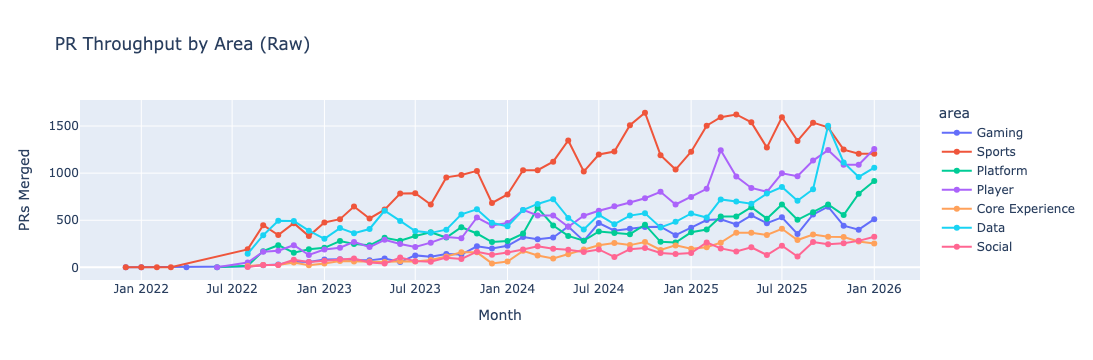

In [76]:
# Raw throughput over time by area
fig = px.line(df_by_area, x='month', y='prs_merged', color='area',
              title='PR Throughput by Area (Raw)',
              markers=True)
fig.update_layout(yaxis_title='PRs Merged', xaxis_title='Month')
fig.show()

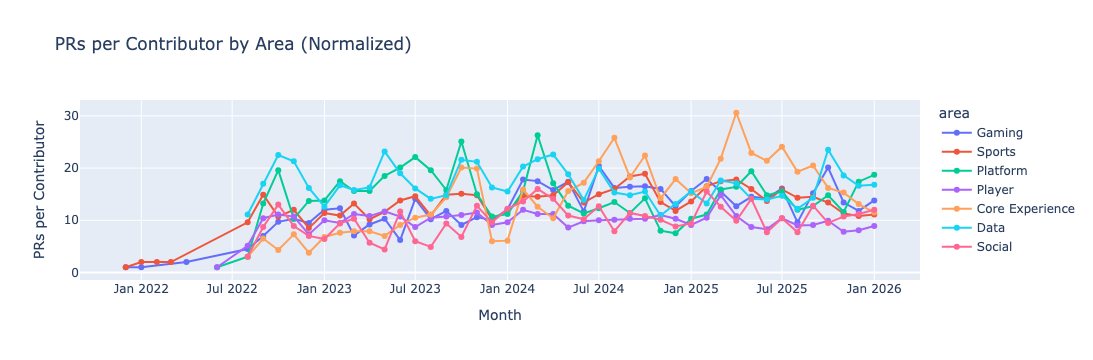

In [77]:
# Normalized throughput (PRs per contributor) by area
fig = px.line(df_by_area, x='month', y='prs_per_contributor', color='area',
              title='PRs per Contributor by Area (Normalized)',
              markers=True)
fig.update_layout(yaxis_title='PRs per Contributor', xaxis_title='Month')
fig.show()

# Export manually: fig.write_image('pr-throughput-by-area-normalized.png')

In [78]:
# Summary table: Area performance (last 3 months vs previous 3 months)
areas_str = "', '".join(AREAS)

df_area_summary = run_query(f"""
WITH pr_flattened AS (
  SELECT
    pr.github_created_at,
    pr.author_id,
    f.value::string as area
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.github_created_at IS NOT NULL
    AND f.value::string IN ('{areas_str}')
),
recent AS (
  SELECT 
    area,
    COUNT(*) as prs_recent,
    COUNT(DISTINCT author_id) as contributors_recent
  FROM pr_flattened
  WHERE github_created_at >= DATEADD('month', -3, CURRENT_DATE)
  GROUP BY 1
),
previous AS (
  SELECT 
    area,
    COUNT(*) as prs_previous,
    COUNT(DISTINCT author_id) as contributors_previous
  FROM pr_flattened
  WHERE github_created_at >= DATEADD('month', -6, CURRENT_DATE)
    AND github_created_at < DATEADD('month', -3, CURRENT_DATE)
  GROUP BY 1
)
SELECT 
  COALESCE(r.area, p.area) as area,
  COALESCE(r.prs_recent, 0) as prs_last_3mo,
  COALESCE(r.contributors_recent, 0) as contributors_last_3mo,
  ROUND(COALESCE(r.prs_recent, 0) * 1.0 / NULLIF(COALESCE(r.contributors_recent, 0), 0), 1) as prs_per_contributor_last_3mo,
  COALESCE(p.prs_previous, 0) as prs_prev_3mo,
  COALESCE(p.contributors_previous, 0) as contributors_prev_3mo,
  ROUND(COALESCE(p.prs_previous, 0) * 1.0 / NULLIF(COALESCE(p.contributors_previous, 0), 0), 1) as prs_per_contributor_prev_3mo,
  CASE WHEN COALESCE(p.prs_previous, 0) > 0 
       THEN ROUND(100.0 * (COALESCE(r.prs_recent, 0) - p.prs_previous) / p.prs_previous, 1)
       ELSE NULL END as prs_growth_pct
FROM recent r
FULL OUTER JOIN previous p ON r.area = p.area
ORDER BY prs_last_3mo DESC
""")

print("Area Performance: Last 3 months vs Previous 3 months")
df_area_summary

Area Performance: Last 3 months vs Previous 3 months


,area,prs_last_3mo,contributors_last_3mo,prs_per_contributor_last_3mo,prs_prev_3mo,contributors_prev_3mo,prs_per_contributor_prev_3mo,prs_growth_pct
0,Sports,3632,121,30.0,4395,116,37.9,-17.4
1,Player,3440,157,21.9,3348,139,24.1,2.7
2,Data,3167,69,45.9,3171,70,45.3,-0.1
3,Platform,2383,52,45.8,1771,50,35.4,34.6
4,Gaming,1398,41,34.1,1603,39,41.1,-12.8
5,Social,870,27,32.2,659,26,25.3,32.0
6,Core Experience,862,24,35.9,915,20,45.8,-5.8


In [79]:
# Area comparison: 6-month average PRs per contributor
# This smooths out month-to-month variance for more reliable comparison

df_by_area['month_dt'] = pd.to_datetime(df_by_area['month'])
six_months_ago = df_by_area['month_dt'].max() - pd.DateOffset(months=6)

df_area_6mo = df_by_area[df_by_area['month_dt'] > six_months_ago].groupby('area').agg({
    'prs_per_contributor': ['mean', 'std', 'min', 'max'],
    'prs_merged': 'sum',
    'contributors': 'mean'
}).round(1)

df_area_6mo.columns = ['avg_prs_per_contributor', 'std', 'min', 'max', 'total_prs', 'avg_contributors']
df_area_6mo = df_area_6mo.sort_values('avg_prs_per_contributor', ascending=False)

print("6-Month Average: PRs per Contributor by Area")
print("=" * 60)
df_area_6mo

6-Month Average: PRs per Contributor by Area


,avg_prs_per_contributor,std,min,max,total_prs,avg_contributors
area,,,,,,
Data,17.0,3.9,12.2,23.5,6168,60.2
Core Experience,16.0,3.5,11.5,20.5,1815,19.3
Platform,14.5,3.0,11.6,18.7,4010,45.8
Gaming,14.0,3.6,9.6,20.1,2913,35.0
Sports,12.6,1.7,10.8,14.5,8025,107.2
Social,10.6,1.8,7.7,12.8,1491,23.0
Player,8.8,0.8,7.8,9.9,6782,129.0


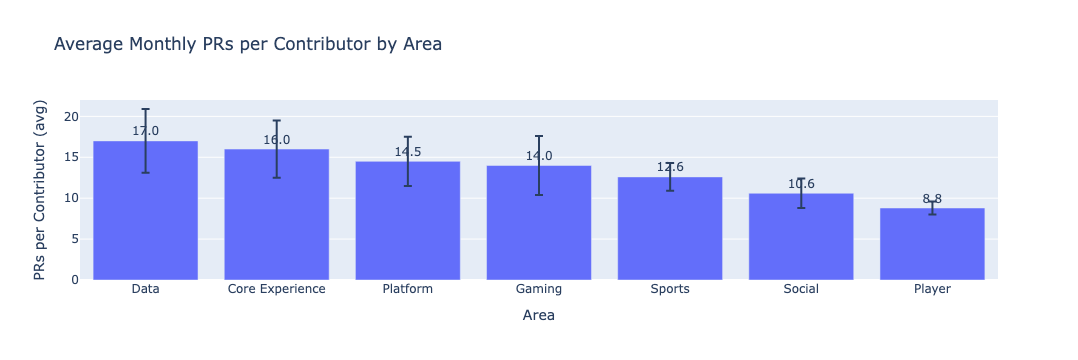


Key finding:
  - Highest: Data (17.0 PRs/contributor)
  - Lowest: Player (8.8 PRs/contributor)
  - Ratio: 1.9x difference


In [80]:
# Bar chart: 6-month average PRs per contributor by area
fig = px.bar(df_area_6mo.reset_index(), 
             x='area', 
             y='avg_prs_per_contributor',
             error_y='std',
             title='Average Monthly PRs per Contributor by Area',
             text='avg_prs_per_contributor')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(yaxis_title='PRs per Contributor (avg)', xaxis_title='Area')
fig.show()

# Export manually: fig.write_image('pr-throughput-by-area-comparison.png')

# Print key insight
highest = df_area_6mo['avg_prs_per_contributor'].idxmax()
lowest = df_area_6mo['avg_prs_per_contributor'].idxmin()
highest_val = df_area_6mo.loc[highest, 'avg_prs_per_contributor']
lowest_val = df_area_6mo.loc[lowest, 'avg_prs_per_contributor']

print(f"\nKey finding:")
print(f"  - Highest: {highest} ({highest_val:.1f} PRs/contributor)")
print(f"  - Lowest: {lowest} ({lowest_val:.1f} PRs/contributor)")
print(f"  - Ratio: {highest_val/lowest_val:.1f}x difference")

## 5. Insights & Summary

Key findings to include in the report.

In [81]:
# Calculate key metrics for the report
latest_month = df_monthly['month'].max()
latest_data = df_monthly[df_monthly['month'] == latest_month].iloc[0]

# Get data from 12 months ago if available
twelve_months_ago = pd.to_datetime(latest_month) - pd.DateOffset(months=12)
yoy_data = df_monthly[df_monthly['month_dt'] <= twelve_months_ago].tail(1)

print("=" * 60)
print("KEY METRICS FOR REPORT")
print("=" * 60)
print(f"\nLatest month ({latest_month}):")
print(f"  - PRs merged: {latest_data['prs_merged']:,}")
print(f"  - Contributors: {latest_data['contributors']:,}")
print(f"  - PRs per contributor: {latest_data['prs_per_contributor']:.1f}")

print(f"\nBaseline (all-time average):")
print(f"  - PRs merged: {df_monthly['prs_merged'].mean():.0f} per month")
print(f"  - PRs per contributor: {df_monthly['prs_per_contributor'].mean():.1f} per month")

if len(yoy_data) > 0:
    yoy_prs = latest_data['prs_merged']
    yoy_prs_prev = yoy_data['prs_merged'].iloc[0]
    yoy_growth = (yoy_prs - yoy_prs_prev) / yoy_prs_prev * 100
    print(f"\nYear-over-year growth:")
    print(f"  - PRs merged: {yoy_growth:+.1f}%")
    
    yoy_per_capita = latest_data['prs_per_contributor']
    yoy_per_capita_prev = yoy_data['prs_per_contributor'].iloc[0]
    yoy_per_capita_growth = (yoy_per_capita - yoy_per_capita_prev) / yoy_per_capita_prev * 100
    print(f"  - PRs per contributor: {yoy_per_capita_growth:+.1f}%")

print("=" * 60)

KEY METRICS FOR REPORT

Latest month (2026-01-01):
  - PRs merged: 8,197
  - Contributors: 553
  - PRs per contributor: 14.8

Baseline (all-time average):
  - PRs merged: 4296 per month
  - PRs per contributor: 14.3 per month

Year-over-year growth:
  - PRs merged: +14.2%
  - PRs per contributor: -20.4%


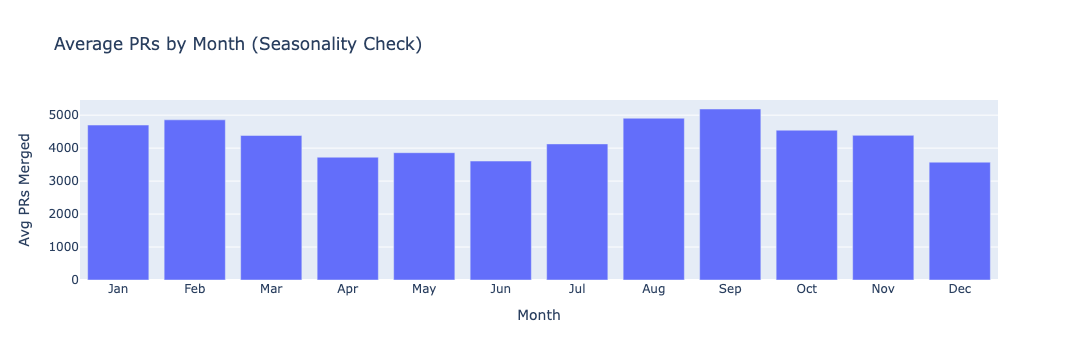


Seasonality patterns:
  - Lowest: Dec (3574 avg)
  - Highest: Sep (5186 avg)


In [82]:
# Seasonality check - are there consistent dips?
df_monthly['month_name'] = df_monthly['month_dt'].dt.strftime('%b')
df_seasonality = df_monthly.groupby('month_num').agg({
    'prs_merged': 'mean',
    'month_name': 'first'
}).sort_index()

fig = px.bar(df_seasonality.reset_index(), x='month_name', y='prs_merged',
             title='Average PRs by Month (Seasonality Check)')
fig.update_layout(xaxis_title='Month', yaxis_title='Avg PRs Merged')
fig.show()

print("\nSeasonality patterns:")
print(f"  - Lowest: {df_seasonality['month_name'].iloc[df_seasonality['prs_merged'].argmin()]} ({df_seasonality['prs_merged'].min():.0f} avg)")
print(f"  - Highest: {df_seasonality['month_name'].iloc[df_seasonality['prs_merged'].argmax()]} ({df_seasonality['prs_merged'].max():.0f} avg)")

## Next Steps

Once we're happy with this analysis, we'll:
1. Update the report markdown with actual numbers and insights
2. Save dashboard-ready queries